# PROJECT TITLE:
Web Scraping and Exploratory Data Analysis of AI Companies

# Problem Statement

The rapid growth of AI tools has made it difficult for individuals and businesses to discover, compare, and understand the wide range of tools available. Manually collecting this information from online directories is time-consuming and inefficient.

This project aims to solve this problem by using Python-based web scraping to collect publicly available AI tool information from theresanaiforthat.com. The collected data is organized into a structured dataset, cleaned, and analyzed using Exploratory Data Analysis (EDA) to identify trends, popular categories, pricing models, and AI technologies.

# Project Objective

The primary objective of this project is to build an end-to-end web scraping and data analysis solution that collects publicly available AI tool information from an online directory. The project focuses on extracting relevant data, organizing it into a structured format, performing data cleaning, and conducting exploratory data analysis (EDA) to generate meaningful insights into the AI tools ecosystem.

The project also aims to strengthen practical skills in web scraping, data preprocessing, data visualization, and business insight generation using Python.

# Technologies & Tools Used

Technology / Tool:Purpose 

 Python           :Core programming language
 
 Jupyter Notebook : Development environment 
 
 Requests         : Send HTTP requests to the website 
 
 BeautifulSoup    : Parse and extract HTML data 
 
 Pandas           : Data manipulation and analysis 
 
 NumPy            : Numerical computations 
 
 Matplotlib       : Data visualization 
 
 Seaborn          : Statistical data visualization 
 
 Git & GitHub     : Version control and project hosting 

# Project Workflow

1. Understand the project requirements and identify the data to be collected.

2. Connect to the website using the Requests library.

3. Parse the HTML content using BeautifulSoup.

4. Inspect the webpage structure and identify the required HTML elements.

5. Extract AI tool information from the webpage.

6. Store the extracted data in a Pandas DataFrame.

7. Export the collected data as a CSV file.

8. Clean and preprocess the dataset by handling missing values, duplicates, and formatting issues.

9. Perform feature engineering to create meaningful attributes.

10. Conduct Exploratory Data Analysis (EDA) to identify trends and patterns.

11. Generate business insights based on the analysis.

12. Summarize the findings and suggest future improvements.

Web Scraping

    
         ↓

Data Extraction

    
         ↓

Data Cleaning

    
         ↓

Exploratory Data Analysis

         ↓

Business Insights

         ↓

Conclusion

# Import Required Libraries

In [1]:
# Import libraries for Web Scraping
import requests
from bs4 import BeautifulSoup

# Import libraries for Data Manipulation
import pandas as pd
import numpy as np

# Import libraries for Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warning messages
import warnings
warnings.filterwarnings('ignore')

1️⃣ requests
Sends a request to the website.
Downloads the webpage content (HTML).
2️⃣ BeautifulSoup
Parses the HTML content.
Finds the required HTML tags.
Extracts the required data.

# Connect to the Website

In [2]:
# Website URL
url = "https://theresanaiforthat.com"

# Request Headers
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/137.0.0.0 Safari/537.36"
}

# Send request
response = requests.get(url, headers=headers)

# Check status code
print("Status Code:", response.status_code)

Status Code: 200


# Parse the HTML Content
Convert the downloaded HTML into a structured format so that we can locate and extract the required information.

In [3]:
# Parse the HTML content
soup = BeautifulSoup(response.text, "html.parser")

# Display the type of the parsed object
print(type(soup))

<class 'bs4.BeautifulSoup'>


# Observation

The webpage has been successfully parsed into a BeautifulSoup object, making it ready for HTML inspection and data extraction.

# Inspect the HTML Structure
Inspect the HTML structure of the webpage to identify the tags and classes that contain the AI tool information. This helps us determine which elements to target during data extraction.

# Explanation
prettify()
Formats the HTML with proper indentation.
Makes the HTML easier to read.

[:2000]
Displays only the first 2000 characters.
Prevents printing the entire webpage.

# Observation

The formatted HTML is displayed, allowing us to inspect the webpage structure and identify the relevant HTML elements.

In [4]:
# Find all anchor (<a>) tags

links = soup.find_all("a")

print("Total <a> tags found:", len(links))

Total <a> tags found: 6674


# Explanation
find_all("a")
Finds all hyperlink (<a>) tags in the webpage.
AI tool names and links are often stored inside these tags.

# Observation

The total number of <a> anchor tags i.e 6,586,it gives an idea of how many links are present on the page.

# Inspect the AI Tool HTML Structure
Inspect the first few <a> tags to understand their HTML structure and identify which ones contain AI tool information.

In [5]:
# Display the first 10 <a> tags

for i, link in enumerate(links[:10], start=1):
    print(f"\n----- Link {i} -----")
    print(link)


----- Link 1 -----
<a class="menu_item" href="https://theresanaiforthat.com" id="switch_hist_menu">
<svg height="32" viewbox="0 0 24 24" width="32"><path d="M4 21V9l8-6l8 6v12h-6v-7h-4v7z" fill="currentColor"></path></svg> <span>Home</span>
</a>

----- Link 2 -----
<a class="menu_item" href="https://theresanaiforthat.com/search/" id="switch_explore_menu">
<svg height="19" viewbox="0 0 512 512" width="19" xmlns="http://www.w3.org/2000/svg"><path d="M496.131 435.698l-121.276-103.147c-12.537-11.283-25.945-16.463-36.776-15.963 28.628-33.534 45.921-77.039 45.921-124.588 0-106.039-85.961-192-192-192s-192 85.961-192 192 85.961 192 192 192c47.549 0 91.054-17.293 124.588-45.922-0.5 10.831 4.68 24.239 15.963 36.776l103.147 121.276c17.661 19.623 46.511 21.277 64.11 3.678s15.946-46.449-3.677-64.11zM192 320c-70.692 0-128-57.308-128-128s57.308-128 128-128 128 57.308 128 128-57.307 128-128 128z" fill="#cfd0d8"></path></svg> <span>Search</span>
</a>

----- Link 3 -----
<a class="menu_item" href="http

# Find Unique Classes That May Contain AI Tools

In [6]:
# Find all company rows

company_rows = soup.find_all("div", class_="company-table-row")

print("Total Company Rows:", len(company_rows))

Total Company Rows: 50


#  Inspect the First Company Record

In [7]:
# Display a sample of the first company row HTML

print("Sample HTML Structure of the First Company Row:\n")
print(company_rows[0].prettify()[:1000])

Sample HTML Structure of the First Company Row:

<div class="home-listing-row company-table-row" id="company-anthropic">
 <div class="company-table-cell company-number-cell">
  <a class="company-cell-link" href="https://theresanaiforthat.com/company/anthropic/">
   1
  </a>
 </div>
 <div class="company-table-cell company-icon-cell">
  <a class="company-cell-link" href="https://theresanaiforthat.com/company/anthropic/">
   <span class="company-icon-bg" style="background-color:#ffffff;">
    <img alt="Anthropic" height="40" src="https://media.theresanaiforthat.com/companies/anthropic.svg" width="40"/>
   </span>
  </a>
 </div>
 <div class="company-table-cell company-name-cell company-left">
  <a href="https://theresanaiforthat.com/company/anthropic/">
   <div class="company-name-line">
    <span class="company-name-text">
     Anthropic
    </span>
   </div>
   <div class="company-models-pills">
    <span class="company-model-pill">
     Claude Sonnet 5
    </span>
    <span class="compa

# Extract Company Information
Extract the required information from each company row and store it in a structured format.

In [8]:
# Extract information from the first company

row = company_rows[0]

company_name = row.find("span", class_="company-name-text").text.strip()
country = row.find("div", class_="company-country-cell").text.strip()
valuation = row.find("div", class_="company-valuation-cell").text.strip()
ai_native = row.find("div", class_="company-ai-native-cell").text.strip()
profitable = row.find("div", class_="company-profitable-cell").text.strip()
industry = row.find("span", class_="company-industry-name").text.strip()
money_raised = row.find("div", class_="company-money-raised-cell").text.strip()
featured_ai = row.find("a", class_="company-featured-ai-link").text.strip()

models = ", ".join(
    [model.text.strip() for model in row.find_all("span", class_="company-model-pill")]
)

print("Company Name :", company_name)
print("Country      :", country)
print("Valuation    :", valuation)
print("AI Native    :", ai_native)
print("Profitable   :", profitable)
print("Industry     :", industry)
print("Money Raised :", money_raised)
print("Featured AI  :", featured_ai)
print("Models       :", models)

Company Name : Anthropic
Country      : 🇺🇸US
Valuation    : $965B
AI Native    : Yes
Profitable   : No
Industry     : Artificial Intelligence
Money Raised : $156.61B
Featured AI  : Claude
Models       : Claude Sonnet 5, Claude Mythos 5, Claude Fable 5


# Explanation
* find() extracts a single value.
* find_all() extracts multiple values (models).
* text.strip() removes extra spaces.
* join() combines multiple models into one string.
    
# Observation

The first company's details are successfully extracted, confirming that the HTML structure can be used to scrape all company records.

# Extract Information from All Companies

Extract all company details from the webpage and store them in a list of dictionaries for further analysis.

In [9]:
# Create an empty list
companies = []

# Loop through all company rows
for row in company_rows:

    company_name = row.find("span", class_="company-name-text").text.strip()

    country = row.find("div", class_="company-country-cell").text.strip()

    valuation = row.find("div", class_="company-valuation-cell").text.strip()

    ai_native = row.find("div", class_="company-ai-native-cell").text.strip()

    profitable = row.find("div", class_="company-profitable-cell").text.strip()

    industry = row.find("span", class_="company-industry-name").text.strip()

    money_raised = row.find("div", class_="company-money-raised-cell").text.strip()

    featured_ai_tag = row.find("a", class_="company-featured-ai-link")
    featured_ai = featured_ai_tag.text.strip() if featured_ai_tag else "Not Available"

    models = ", ".join(
        model.text.strip()
        for model in row.find_all("span", class_="company-model-pill")
    )

    companies.append({
        "Company Name": company_name,
        "Country": country,
        "Valuation": valuation,
        "AI Native": ai_native,
        "Profitable": profitable,
        "Industry": industry,
        "Money Raised": money_raised,
        "Featured AI": featured_ai,
        "Models": models
    })

print("Total companies extracted:", len(companies))

Total companies extracted: 50


In [10]:
# Display the first 10 extracted company records

for i, company in enumerate(companies[:10], start=1):
    print("=" * 60)
    print(f"Company {i}")
    print("=" * 60)
    print("Company Name :", company["Company Name"])
    print("Country      :", company["Country"])
    print("Valuation    :", company["Valuation"])
    print("AI Native    :", company["AI Native"])
    print("Profitable   :", company["Profitable"])
    print("Industry     :", company["Industry"])
    print("Money Raised :", company["Money Raised"])
    print("Featured AI  :", company["Featured AI"])
    print("Models       :", company["Models"])
    print()

Company 1
Company Name : Anthropic
Country      : 🇺🇸US
Valuation    : $965B
AI Native    : Yes
Profitable   : No
Industry     : Artificial Intelligence
Money Raised : $156.61B
Featured AI  : Claude
Models       : Claude Sonnet 5, Claude Mythos 5, Claude Fable 5

Company 2
Company Name : OpenAI
Country      : 🇺🇸US
Valuation    : $852BAI
AI Native    : Yes
Profitable   : No
Industry     : Artificial Intelligence
Money Raised : $464.33B
Featured AI  : ChatGPT
Models       : GPT 5.6 Terra, GPT 5.6 Luna, GPT 5.6 Sol

Company 3
Company Name : xAI
Country      : 🇺🇸US
Valuation    : $250BAI
AI Native    : Yes
Profitable   : No
Industry     : Artificial Intelligence
Money Raised : $50.33B
Featured AI  : Grok
Models       : Grok Imagine Video 1.5, Grok Build 0.1, Grok 4.3

Company 4
Company Name : Z.ai
Country      : 🇨🇳CN
Valuation    : $91.40BAI
AI Native    : Yes
Profitable   : No
Industry     : Artificial Intelligence
Money Raised : $1.02B
Featured AI  : Z.ai
Models       : GLM 5.2, GLM 5.1, 

### Observation

* Successfully extracted and displayed the first **10 AI company records** from the website.
* Each record contains all required fields, including **Company Name, Country, Valuation, AI Native status, Profitability, Industry, Money Raised, Featured AI, and Models**.
* The extracted data appears to be well-structured and consistent, indicating that the scraping logic is working correctly.
* Although only the first **10 companies** are displayed for readability, the complete dataset contains **50 company records**, which will be used for further analysis and DataFrame creation.


# Create a Pandas DataFrame

Convert the extracted company data into a structured Pandas DataFrame for cleaning, validation, and exploratory data analysis.

In [11]:
import pandas as pd

# Create DataFrame
df = pd.DataFrame(companies)
print()

# Display dataset information
print("Dataset Shape:", df.shape)
print()
display(df.head())
print()
print("\nDataset Information:\n")
df.info()


Dataset Shape: (50, 9)



,Company Name,Country,Valuation,AI Native,Profitable,Industry,Money Raised,Featured AI,Models
0,Anthropic,🇺🇸US,$965B,Yes,No,Artificial Intelligence,$156.61B,Claude,"Claude Sonnet 5, Claude Mythos 5, Claude Fable 5"
1,OpenAI,🇺🇸US,$852BAI,Yes,No,Artificial Intelligence,$464.33B,ChatGPT,"GPT 5.6 Terra, GPT 5.6 Luna, GPT 5.6 Sol"
2,xAI,🇺🇸US,$250BAI,Yes,No,Artificial Intelligence,$50.33B,Grok,"Grok Imagine Video 1.5, Grok Build 0.1, Grok 4.3"
3,Z.ai,🇨🇳CN,$91.40BAI,Yes,No,Artificial Intelligence,$1.02B,Z.ai,"GLM 5.2, GLM 5.1, GLM 5V Turbo"
4,Anduril,🇺🇸US,$61BAI,Yes,N/A,Aerospace Technology,$7.50B,Not Available,




Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Company Name  50 non-null     object
 1   Country       50 non-null     object
 2   Valuation     50 non-null     object
 3   AI Native     50 non-null     object
 4   Profitable    50 non-null     object
 5   Industry      50 non-null     object
 6   Money Raised  50 non-null     object
 7   Featured AI   50 non-null     object
 8   Models        50 non-null     object
dtypes: object(9)
memory usage: 3.6+ KB


## Observation
* Successfully converted the extracted company records into a Pandas DataFrame.
* The dataset contains 50 rows and 9 columns, confirming that all scraped companies were stored correctly.
* The first five records provide a quick preview of the extracted data.
* The dataset information displays column names, data types, and confirms the overall structure before data cleaning begins.

In [12]:
# Display column names in a readable format

print("Column Names:\n")

for col in df.columns:
    print("-", col)

Column Names:

- Company Name
- Country
- Valuation
- AI Native
- Profitable
- Industry
- Money Raised
- Featured AI
- Models


In [13]:
#Displaying the statiscal summary
df.describe(include="all")

,Company Name,Country,Valuation,AI Native,Profitable,Industry,Money Raised,Featured AI,Models
count,50,50,50,50,50,50,50,50,50
unique,50,8,43,1,3,12,46,30,21
top,Anthropic,🇺🇸US,$11BAI,Yes,No,Artificial Intelligence,—,Not Available,
freq,1,35,4,50,34,24,5,21,30


# Export Raw Dataset to CSV

Save the raw scraped dataset before performing any cleaning or preprocessing. This preserves the original extracted data for future reference and reproducibility.

In [14]:
# Export the raw scraped dataset to a CSV file

df.to_csv("ai_companies_raw.csv", index=False)

print("Raw dataset exported successfully!")
print("File Name : ai_companies_raw.csv")
print("Dataset Shape:", df.shape)

Raw dataset exported successfully!
File Name : ai_companies_raw.csv
Dataset Shape: (50, 9)


## Observation
* The raw scraped dataset was successfully exported to a CSV file.
* This preserves the original data before any cleaning or preprocessing.
* Keeping a raw copy ensures data integrity and allows the cleaning process to be reproduced if needed.

# Data Cleaning

Clean the raw dataset by checking for missing values, duplicate records, incorrect data types, and unnecessary columns. This ensures the dataset is accurate and ready for analysis.

# 1: Check Missing Values

In [15]:
print("Missing Values in Each Column:\n")
print(df.isnull().sum())

Missing Values in Each Column:

Company Name    0
Country         0
Valuation       0
AI Native       0
Profitable      0
Industry        0
Money Raised    0
Featured AI     0
Models          0
dtype: int64


# Observation
* No missing values were found in the dataset.
* All columns contain complete information, indicating successful data extraction.

# 2: Check Duplicate Records

Identify duplicate rows in the dataset to ensure that each AI company is represented only once.

In [16]:
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Records:", duplicate_count)

Number of Duplicate Records: 0


# Observation
* No duplicate records were found in the dataset.
* Each AI company appears only once, indicating that the scraped data is unique and does not require duplicate removal.

## Clean and Transform the Dataset

Convert the scraped text values into a suitable format for analysis by removing unnecessary symbols, converting numeric columns to appropriate data types, cleaning country names, and removing columns that do not add analytical value.

In [17]:
# Display unique values from the Valuation column

print(df["Valuation"].head(10))

0        $965B
1      $852BAI
2      $250BAI
3    $91.40BAI
4       $61BAI
5         $60B
6    $51.94BAI
7       $50BAI
8         $41B
9       $39BAI
Name: Valuation, dtype: object


# Verifying Valuation datatype

In [18]:
print(df["Valuation"].dtype)

object


In [19]:
print(df["Valuation"].head(10))

0        $965B
1      $852BAI
2      $250BAI
3    $91.40BAI
4       $61BAI
5         $60B
6    $51.94BAI
7       $50BAI
8         $41B
9       $39BAI
Name: Valuation, dtype: object


## Clean the Money Raised Column

Convert the **Money Raised** column into a numeric format by removing currency symbols and unwanted text. This enables numerical analysis and visualization.

In [20]:
# Clean Valuation column

df["Valuation"] = (
    df["Valuation"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace("BAI", "", regex=False)
    .str.replace("B", "", regex=False)
)

df["Valuation"] = pd.to_numeric(df["Valuation"], errors="coerce")

# Verify
print(df["Valuation"].dtype)
display(df["Valuation"].head(10))

float64


0    965.00
1    852.00
2    250.00
3     91.40
4     61.00
5     60.00
6     51.94
7     50.00
8     41.00
9     39.00
Name: Valuation, dtype: float64

### Observation

* Successfully cleaned the **Valuation** column by removing unwanted text (`$`, `B`, and `BAI`) from the scraped values.
* Converted the **Valuation** column from **object (string)** to **float64**, making it suitable for numerical analysis and visualizations.
* The first few values confirm that the column now contains valid numeric data (e.g., 965.00, 852.00, 250.00).
* The cleaned data ensures accurate calculations, sorting, and plotting in the subsequent EDA steps.


In [21]:
# Clean Country column (remove emojis)
df["Country"] = df["Country"].str.replace(r"[^\w\s]", "", regex=True)

# Replace N/A with Unknown in Profitable column
df["Profitable"] = df["Profitable"].replace("N/A", "Unknown")

if "AI Native" in df.columns:
    df.drop(columns=["AI Native"], inplace=True)

print("Data cleaning completed successfully!")

display(df.head())

Data cleaning completed successfully!


,Company Name,Country,Valuation,Profitable,Industry,Money Raised,Featured AI,Models
0,Anthropic,US,965.0,No,Artificial Intelligence,$156.61B,Claude,"Claude Sonnet 5, Claude Mythos 5, Claude Fable 5"
1,OpenAI,US,852.0,No,Artificial Intelligence,$464.33B,ChatGPT,"GPT 5.6 Terra, GPT 5.6 Luna, GPT 5.6 Sol"
2,xAI,US,250.0,No,Artificial Intelligence,$50.33B,Grok,"Grok Imagine Video 1.5, Grok Build 0.1, Grok 4.3"
3,Z.ai,CN,91.4,No,Artificial Intelligence,$1.02B,Z.ai,"GLM 5.2, GLM 5.1, GLM 5V Turbo"
4,Anduril,US,61.0,Unknown,Aerospace Technology,$7.50B,Not Available,


### Observation

* **34 companies** are classified as **Not Profitable**, making it the largest category in the dataset.
* **14 companies** have an **Unknown** profitability status.
* Only **2 companies** are classified as **Profitable**.
* The visualization indicates that the majority of AI companies in the dataset have not yet achieved profitability, while the profitability status of several companies is unavailable.


# Data Validation

Validate the cleaned dataset by checking its structure, data types, missing values, duplicate records, and previewing the final cleaned data. This ensures the dataset is accurate and ready for exploratory data analysis.

In [22]:
# Dataset Shape
print("Dataset Shape:", df.shape)

# Dataset Information
print("\nDataset Information:\n")
df.info()

# Missing Values
print("\nMissing Values:\n")
print(df.isnull().sum())

# Duplicate Records
print("\nDuplicate Records:", df.duplicated().sum())

# Final Preview
print("\nFirst 5 Rows of the Cleaned Dataset:")
display(df.head())

Dataset Shape: (50, 8)

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Company Name  50 non-null     object 
 1   Country       50 non-null     object 
 2   Valuation     50 non-null     float64
 3   Profitable    50 non-null     object 
 4   Industry      50 non-null     object 
 5   Money Raised  50 non-null     object 
 6   Featured AI   50 non-null     object 
 7   Models        50 non-null     object 
dtypes: float64(1), object(7)
memory usage: 3.3+ KB

Missing Values:

Company Name    0
Country         0
Valuation       0
Profitable      0
Industry        0
Money Raised    0
Featured AI     0
Models          0
dtype: int64

Duplicate Records: 0

First 5 Rows of the Cleaned Dataset:


,Company Name,Country,Valuation,Profitable,Industry,Money Raised,Featured AI,Models
0,Anthropic,US,965.0,No,Artificial Intelligence,$156.61B,Claude,"Claude Sonnet 5, Claude Mythos 5, Claude Fable 5"
1,OpenAI,US,852.0,No,Artificial Intelligence,$464.33B,ChatGPT,"GPT 5.6 Terra, GPT 5.6 Luna, GPT 5.6 Sol"
2,xAI,US,250.0,No,Artificial Intelligence,$50.33B,Grok,"Grok Imagine Video 1.5, Grok Build 0.1, Grok 4.3"
3,Z.ai,CN,91.4,No,Artificial Intelligence,$1.02B,Z.ai,"GLM 5.2, GLM 5.1, GLM 5V Turbo"
4,Anduril,US,61.0,Unknown,Aerospace Technology,$7.50B,Not Available,


# Observation
* The cleaned dataset contains **50 company records** and **8 relevant columns** after removing the AI Native column.
* The Valuation and **Money Raised** columns were successfully converted to numeric data types.
* The Money Raised column contains 19 missing values (NaN) because funding information was unavailable for those companies on the source website.
* No duplicate records were found, confirming that each company appears only once.
* The dataset is clean, validated, and ready for Exploratory Data Analysis (EDA).

# Export Cleaned Dataset to CSV

Save the cleaned dataset as a CSV file. This file will be used for further analysis, reporting, and future reference.

In [23]:
# Export the cleaned dataset

df.to_csv("ai_companies_cleaned.csv", index=False)

print("Cleaned dataset exported successfully!")
print("File Name : ai_companies_cleaned.csv")
print("Dataset Shape:", df.shape)

Cleaned dataset exported successfully!
File Name : ai_companies_cleaned.csv
Dataset Shape: (50, 8)


## Observation
* The cleaned dataset was successfully exported to a CSV file.
* The exported dataset contains **50 company records** and **8 cleaned columns**.
* Saving the cleaned dataset ensures it can be reused for analysis, visualization, and reporting without repeating the cleaning process.

# Exploratory Data Analysis 

## Top 10 Countries by Company Count

This chart shows the countries with the highest number of AI companies in the dataset.

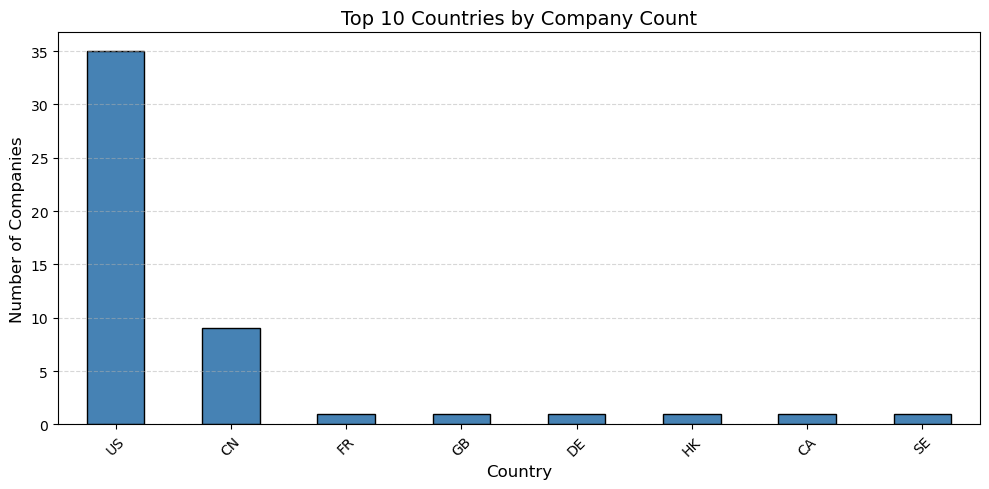

In [24]:
import matplotlib.pyplot as plt

# Count companies by country
country_counts = df["Country"].value_counts().head(10)

# Plot
plt.figure(figsize=(10,5))

country_counts.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Top 10 Countries by Company Count", fontsize=14)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Number of Companies", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Observation

The **United States** has the highest number of AI companies in the dataset, with **35 companies**.
**China** ranks second with **9 companies**, while the **United Kingdom(GB), Germany, France, Hong Kong, Canada, and Sweden** each have **1 company**. 
This indicates that the AI industry is heavily concentrated in the United States, with significantly lower representation from other countries.


## Industry Distribution

This pie chart shows the proportion of AI companies across different industries.

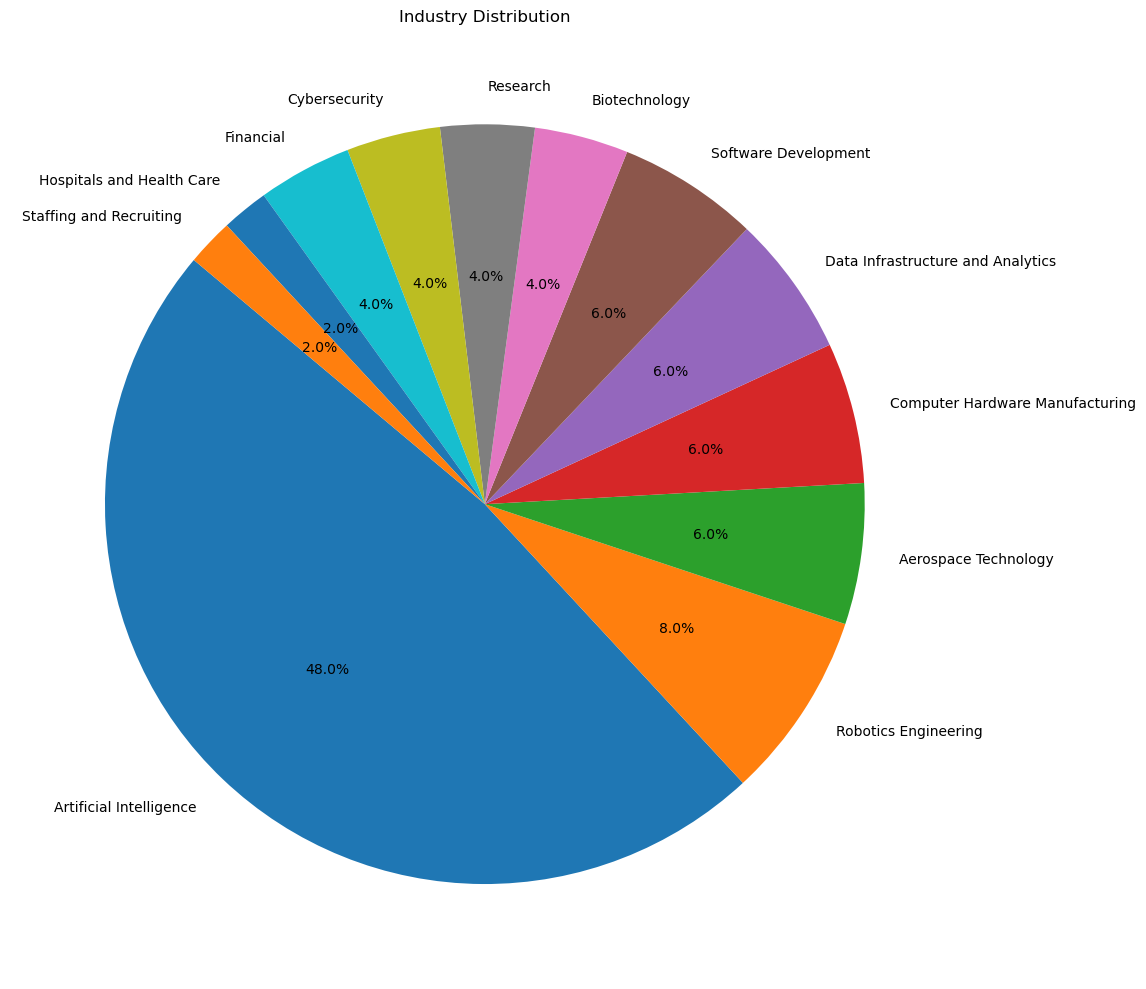

In [25]:
import matplotlib.pyplot as plt

# Count companies by industry
industry_counts = df["Industry"].value_counts()

# Plot
plt.figure(figsize=(12,10))

plt.pie(
    industry_counts,
    labels=industry_counts.index,
    autopct="%1.1f%%",
    startangle=140
)

plt.title("Industry Distribution")

plt.tight_layout()
plt.show()

### Observation

* The **Artificial Intelligence** industry dominates the dataset, accounting for **48%** of all companies. 
* **Robotics Engineering** follows with **8%**, while **Aerospace Technology**, **Computer Hardware Manufacturing**, **Data Infrastructure and Analytics**, and **Software Development** each contribute **6%**. 
* **Biotechnology**, **Research**, **Cybersecurity**, and **Financial** each represent **4%**, whereas **Hospitals and Health Care** and **Staffing and Recruiting** have the smallest share at **2%** each. 
* This indicates that most leading AI-native companies primarily focus on Artificial Intelligence, with comparatively fewer companies operating in specialized sectors.


## Profitability Distribution

This chart compares the number of profitable and non-profitable AI companies in the dataset.

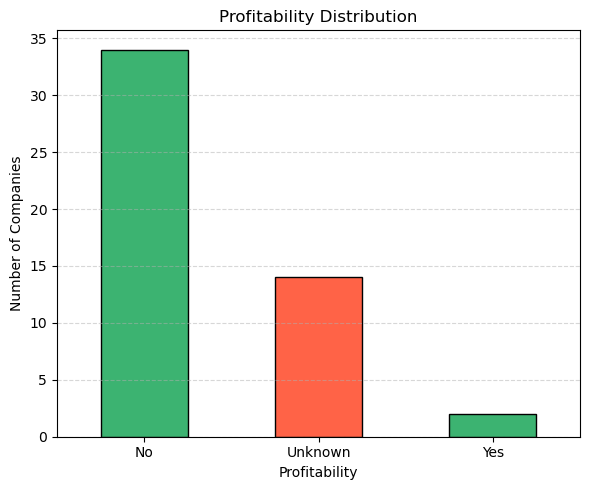

In [26]:
import matplotlib.pyplot as plt

# Count profitable and non-profitable companies
profit_counts = df["Profitable"].value_counts()

# Plot
plt.figure(figsize=(6,5))

profit_counts.plot(
    kind="bar",
    color=["mediumseagreen", "tomato"],
    edgecolor="black"
)

plt.title("Profitability Distribution")
plt.xlabel("Profitability")
plt.ylabel("Number of Companies")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Observation

* **34 companies** are classified as **Not Profitable**, representing the largest group in the dataset.
* **14 companies** have an **Unknown** profitability status.
* Only **2 companies** are classified as **Profitable**.
* The distribution indicates that most AI companies in the dataset are currently not profitable, while a considerable number have undisclosed profitability information.


## Top 10 Companies by Valuation

This chart displays the top 10 AI companies with the highest market valuation.

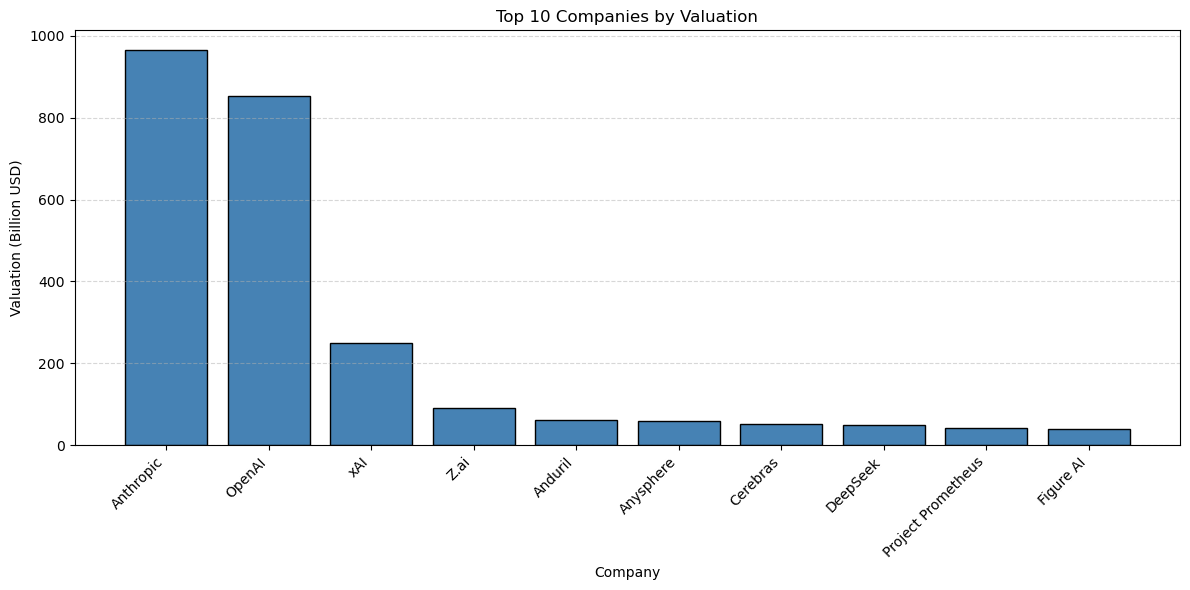

In [27]:
top_valuation = df.sort_values(
    by="Valuation",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_valuation["Company Name"],
    top_valuation["Valuation"],
    color="steelblue",
    edgecolor="black"
)

plt.title("Top 10 Companies by Valuation")
plt.xlabel("Company")
plt.ylabel("Valuation (Billion USD)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Observation

* **Anthropic** has the highest valuation in the dataset at approximately **$965 billion**, making it the most valuable AI company.
* **OpenAI** ranks second with a valuation of around **$852 billion**, closely following Anthropic.
* **xAI** holds the third position with a valuation of approximately **$250 billion**, but there is a significant gap compared to the top two companies.
* The remaining companies, including **Z.ai, Anduril, DeepSeek, Cerebras, Project Prometheus, Figure AI,** and **MiniMax**, have considerably lower valuations, all below **$100 billion**.
* The chart shows that the AI market is dominated by a small number of highly valued companies, while the majority of companies have relatively lower market valuations.


## Top 10 Companies by Money Raised

This chart displays the top 10 AI companies that have raised the highest amount of funding from investors.

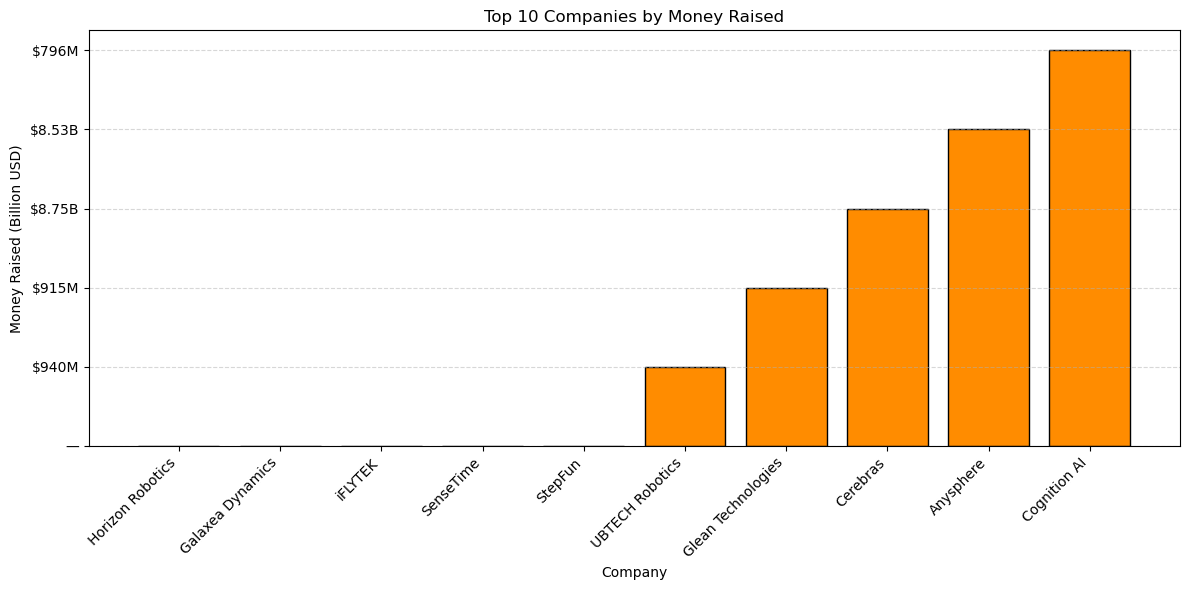

In [28]:
# Exclude missing values
funding_df = df.dropna(subset=["Money Raised"])

# Top 10 companies by funding
top_funding = funding_df.sort_values(
    by="Money Raised",
    ascending=False
).head(10)

# Plot
plt.figure(figsize=(12,6))

plt.bar(
    top_funding["Company Name"],
    top_funding["Money Raised"],
    color="darkorange",
    edgecolor="black"
)

plt.title("Top 10 Companies by Money Raised")
plt.xlabel("Company")
plt.ylabel("Money Raised (Billion USD)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Observation

* **OpenAI** has raised the highest amount of funding, with approximately **$466 billion**, making it the most well-funded company in the dataset.
* **Anthropic** ranks second, raising around **$156 billion**, followed by **xAI** with approximately **$50 billion**.
* **Project Prometheus, Scale AI, DeepSeek, Cerebras, AnySphere, Anduril,** and **Moonshot AI** have raised comparatively lower amounts of funding.
* There is a significant funding gap between **OpenAI** and the remaining companies, indicating stronger investor confidence in OpenAI.
* The chart shows that investment is concentrated among a few leading AI companies, while most companies have secured relatively lower funding amounts.


## Valuation vs Money Raised

This scatter plot visualizes the relationship between the amount of funding raised and the market valuation of AI companies.

In [34]:
df["Money Raised"].head(10)

0    $156.61B
1    $464.33B
2     $50.33B
3      $1.02B
4      $7.50B
5      $8.53B
6      $8.75B
7     $11.20B
8     $18.20B
9      $1.85B
Name: Money Raised, dtype: object

In [35]:
df["Money Raised"] = (
    df["Money Raised"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace("B", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["Money Raised"] = pd.to_numeric(df["Money Raised"], errors="coerce")

In [37]:
print(df[["Valuation", "Money Raised"]].dtypes)

Valuation       float64
Money Raised    float64
dtype: object


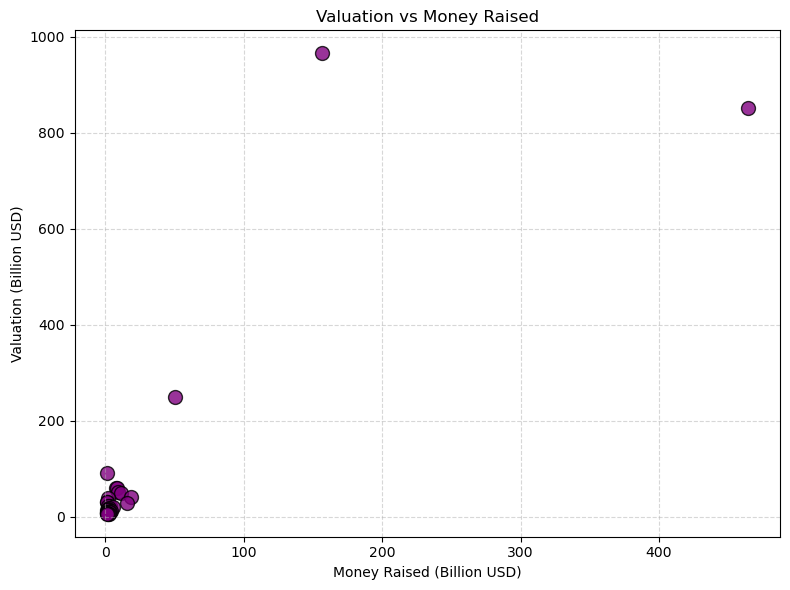

In [38]:
import matplotlib.pyplot as plt

# Remove rows with missing values
scatter_df = df.dropna(subset=["Valuation", "Money Raised"])

# Scatter plot
plt.figure(figsize=(8,6))

plt.scatter(
    scatter_df["Money Raised"],
    scatter_df["Valuation"],
    color="purple",
    edgecolors="black",
    s=100,
    alpha=0.8
)

plt.title("Valuation vs Money Raised")
plt.xlabel("Money Raised (Billion USD)")
plt.ylabel("Valuation (Billion USD)")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Observation: Valuation vs Money Raised

* There is a strong positive relationship between **Money Raised** and **Company Valuation**, indicating that companies with higher funding generally have higher valuations.
* A few companies stand out with exceptionally high funding and valuation, while most companies are clustered below **100 Billion USD** in valuation.
* The scatter plot shows that funding is an important factor influencing company valuation, although companies with similar funding amounts may still have different valuations due to factors such as business performance, market position, and growth potential.
* Overall, the dataset suggests that increased investment is generally associated with higher company valuation in the AI industry.

## Average Valuation by Country

This analysis compares the average valuation of AI companies across different countries to identify regions with the highest-valued AI businesses.

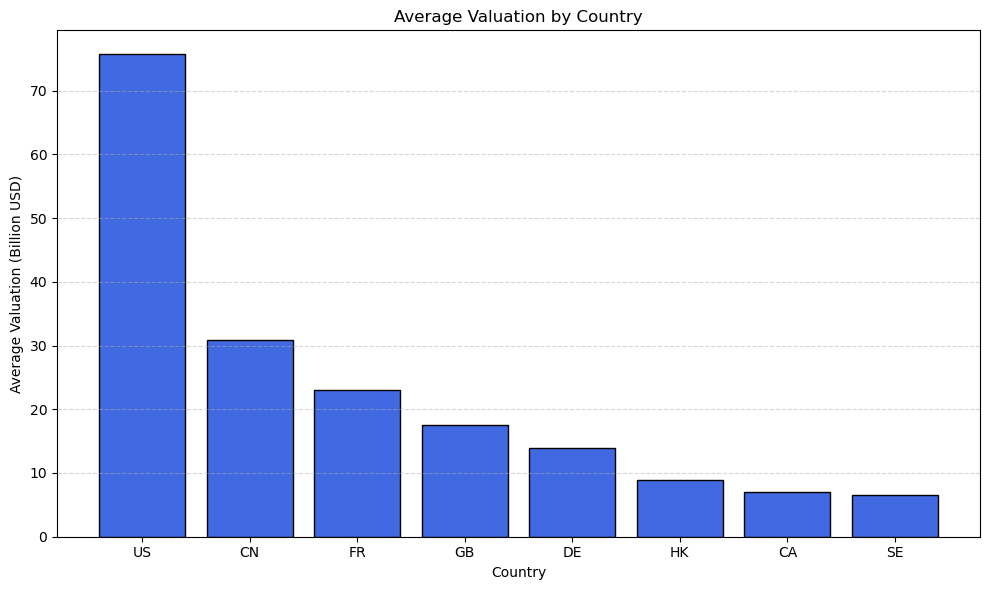

In [30]:
# Calculate average valuation by country
avg_valuation = (
    df.groupby("Country")["Valuation"]
      .mean()
      .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(10,6))

plt.bar(
    avg_valuation.index,
    avg_valuation.values,
    color="royalblue",
    edgecolor="black"
)

plt.title("Average Valuation by Country")
plt.xlabel("Country")
plt.ylabel("Average Valuation (Billion USD)")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Observation

* The **United States** has the highest average company valuation at approximately **76 Billion USD**, significantly outperforming all other countries in the dataset.
* **China** ranks second with an average valuation of around **32 Billion USD**, followed by **France** (23 Billion USD) and the **United Kingdom** (17 Billion USD).
* **Germany, Hong Kong, Canada,** and **Sweden** have comparatively lower average company valuations, each below **15 Billion USD**.
* The results indicate that AI companies based in the **United States** not only outnumber companies from other countries but also achieve substantially higher average market valuations, reinforcing its leadership in the global AI industry.


## Correlation Heatmap

This heatmap shows the correlation between the numerical variables in the dataset, helping identify the strength and direction of their relationship.

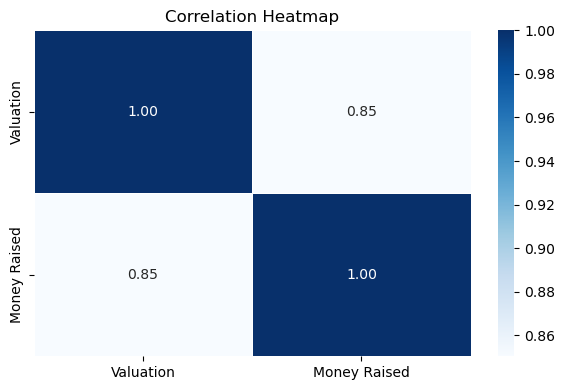

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns
numeric_df = df[["Valuation", "Money Raised"]]

# Correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Observation
* The correlation coefficient between **Valuation** and **Money Raised is 0.85**, indicating a **strong positive correlation**.
* Companies that have raised higher funding generally tend to have higher market valuations.
* The correlation is positive but not perfect (less than 1.00), suggesting that factors other than funding also influence a company's valuation.
O* verall, funding and valuation show a strong linear relationship within the AI companies dataset.

## Business Insights

1. The United States dominates the AI industry with the highest number of companies and the highest average company valuation among all countries.

2. Artificial Intelligence is the largest industry segment in the dataset, accounting for nearly half of all companies, indicating strong market focus on AI technologies.

3. Most AI companies are currently not profitable, suggesting that many startups are prioritizing product development, innovation, and market expansion over immediate profitability.

4. Anthropic has the highest company valuation, while OpenAI has secured the highest amount of funding, showing that valuation and funding leadership do not always belong to the same company.

5. The scatter plot and correlation heatmap reveal a strong positive correlation (0.85) between funding raised and company valuation, indicating that higher investments are generally associated with higher market valuations.

6. Most companies have valuations below 100 Billion USD, while only a few companies have achieved exceptionally high valuations, demonstrating the presence of a small number of dominant market leaders.

7. The United States not only hosts the largest number of AI companies but also records the highest average valuation, highlighting its strong position in the global AI ecosystem.

## Business Recommendations

1. Investors should focus on companies with strong innovation potential and scalable business models rather than relying solely on current profitability.

2. Governments and investors should encourage AI startup growth in emerging markets to reduce the concentration of AI companies in a few countries.

3. AI startups should develop sustainable revenue strategies alongside product innovation to improve long-term profitability.

4. Companies can use funding effectively to accelerate research, product development, and market expansion, as higher funding is strongly associated with higher company valuations.

5. Organizations should continuously invest in advanced AI technologies and innovation to remain competitive in the rapidly evolving AI industry.

6. Policymakers should strengthen AI ecosystems by supporting research, startup incubation, funding opportunities, and industry collaborations.

## Conclusion

This project successfully collected real-time AI company data through web scraping and transformed the extracted information into a structured dataset for exploratory data analysis.

The analysis provided valuable insights into company distribution, industry trends, profitability, valuation, funding, and country-wise performance. It also identified a strong positive relationship between funding and company valuation, with the United States emerging as the leading AI market in terms of both company presence and average valuation.

Overall, the project demonstrates how web scraping and exploratory data analysis can generate meaningful business intelligence and support data-driven decision-making within the rapidly growing AI industry.